In [14]:
"""
import numpy as np	-> সংখ্যা ও array নিয়ে দ্রুত হিসাব করার জন্য।

import pandas as pd	-> CSV/Excel data table আকারে পড়া ও কাজ করার জন্য।

import matplotlib.pyplot as plt	->  Graph আঁকার জন্য।

import seaborn as sns	->  সুন্দর statistical graph আঁকার জন্য।

import joblib	->  Model save/load করার জন্য।

train_test_split  ->  Data কে train ও test ভাগ করে।

LabelEncoder  ->   Text category (যেমন Male/Female) কে number এ বদলায়।

StandardScaler ->  Data scale/normalize করে।

LinearRegression  ->   Linear Regression model তৈরি করে।

mean_squared_error  ->	Prediction error মাপে (MSE)।

r2_score  -> Model কত ভালো fit করেছে (R²) মাপে।

mean_absolute_error  ->	 Average absolute error (MAE) মাপে।

"""

'\nimport numpy as np\t-> সংখ্যা ও array নিয়ে দ্রুত হিসাব করার জন্য।\n\nimport pandas as pd\t-> CSV/Excel data table আকারে পড়া ও কাজ করার জন্য।\n\nimport matplotlib.pyplot as plt\t->  Graph আঁকার জন্য।\n\nimport seaborn as sns\t->  সুন্দর statistical graph আঁকার জন্য।\n\nimport joblib\t->  Model save/load করার জন্য।\n\ntrain_test_split  ->  Data কে train ও test ভাগ করে।\n\nLabelEncoder  ->   Text category (যেমন Male/Female) কে number এ বদলায়।\n\nStandardScaler ->  Data scale/normalize করে।\n\nLinearRegression  ->   Linear Regression model তৈরি করে।\n\nmean_squared_error  ->\tPrediction error মাপে (MSE)।\n\nr2_score  -> Model কত ভালো fit করেছে (R²) মাপে।\n\nmean_absolute_error  ->\t Average absolute error (MAE) মাপে।\n\n'

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error

In [3]:
df=pd.read_csv("/Users/jayanto/Downloads/insurance.csv")
print("print 1st 5 rows\n")
print(df.head())
print("\nprint last 5 rows\n")
print(df.tail())

print("\n print the info\n")
print(df.info())
print("\n show row and columns:\n")
print(f"rows:{df.shape[0]},columns:{df.shape[1]}")

print 1st 5 rows

    age     sex     bmi  children smoker     region   charges
0  19.0  female  27.900         0    yes  southwest  16884.92
1  18.0    male  33.770         1     no  southeast   1725.55
2  28.0    male  33.000         3     no  southeast   4449.46
3  33.0    male  22.705         0     no  northwest  21984.47
4  32.0    male  28.880         0     no  northwest   3866.86

print last 5 rows

     age        sex     bmi  children smoker     region   charges
26  63.0     female  23.085         0     no  northwest  14451.84
27  55.0  northwest  32.775         2     no  northwest  12268.63
28  23.0       male  17.385         1     no  northwest   2775.19
29  31.0       male  36.300         2    yes  southwest  38711.00
30   NaN        NaN  36.300         2    yes  southwest  38711.00

 print the info

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31 entries, 0 to 30
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  ----

In [5]:
print("column er null value sum show korbe\nf")

print(df.isnull().sum())

column er null value sum show korbe
f
age         1
sex         1
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [6]:
df['age'] = df['age'].fillna(df['age'].median())
df['sex'] = df['sex'].fillna(df['sex'].mode()[0])
df['bmi'] = df['bmi'].fillna(df['bmi'].median())

print(f"Total Nulls Remaining: {df.isnull().sum().sum()}")

print("\n--- 2.2 Handling Duplicate Rows ---")
print(f"Duplicate rows found: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)
print(f"Shape after removing duplicates: {df.shape}")

print("\n--- 2.3 Handling Outliers (IQR Capping on BMI) ---")
Q1 = df['bmi'].quantile(0.25)
Q3 = df['bmi'].quantile(0.75)
IQR = Q1 - Q3
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

Total Nulls Remaining: 0

--- 2.2 Handling Duplicate Rows ---
Duplicate rows found: 0
Shape after removing duplicates: (31, 7)

--- 2.3 Handling Outliers (IQR Capping on BMI) ---


In [9]:

"""
Print a heading
print("\n--- 3.1 Encoding Categorical Text Columns ---")

# Create LabelEncoder objects
le_sex = LabelEncoder()
le_smoker = LabelEncoder()
le_region = LabelEncoder()

# Convert 'sex' column into numbers
df['sex'] = le_sex.fit_transform(df['sex'].astype(str))

# Convert 'smoker' column into numbers
df['smoker'] = le_smoker.fit_transform(df['smoker'].astype(str))

# Convert 'region' column into numbers
df['region'] = le_region.fit_transform(df['region'].astype(str))

# Show the first 5 rows after encoding
print("Encoded sample data:")
print(df[['sex', 'smoker', 'region']].head())

"""

'\nPrint a heading\nprint("\n--- 3.1 Encoding Categorical Text Columns ---")\n\n# Create LabelEncoder objects\nle_sex = LabelEncoder()\nle_smoker = LabelEncoder()\nle_region = LabelEncoder()\n\n# Convert \'sex\' column into numbers\ndf[\'sex\'] = le_sex.fit_transform(df[\'sex\'].astype(str))\n\n# Convert \'smoker\' column into numbers\ndf[\'smoker\'] = le_smoker.fit_transform(df[\'smoker\'].astype(str))\n\n# Convert \'region\' column into numbers\ndf[\'region\'] = le_region.fit_transform(df[\'region\'].astype(str))\n\n# Show the first 5 rows after encoding\nprint("Encoded sample data:")\nprint(df[[\'sex\', \'smoker\', \'region\']].head())\n\n'

In [10]:

print("\n--- 3.1 Encoding Categorical Text Columns ---")
le_sex = LabelEncoder()
le_smoker = LabelEncoder()
le_region = LabelEncoder()

df['sex'] = le_sex.fit_transform(df['sex'].astype(str))
df['smoker'] = le_smoker.fit_transform(df['smoker'].astype(str))
df['region'] = le_region.fit_transform(df['region'].astype(str))

print("Encoded sample data:")
print(df[['sex', 'smoker', 'region']].head())


--- 3.1 Encoding Categorical Text Columns ---
Encoded sample data:
   sex  smoker  region
0    0       1       3
1    1       0       2
2    1       0       2
3    1       0       1
4    1       0       1



--- 4.1 Generating Visualizations ---


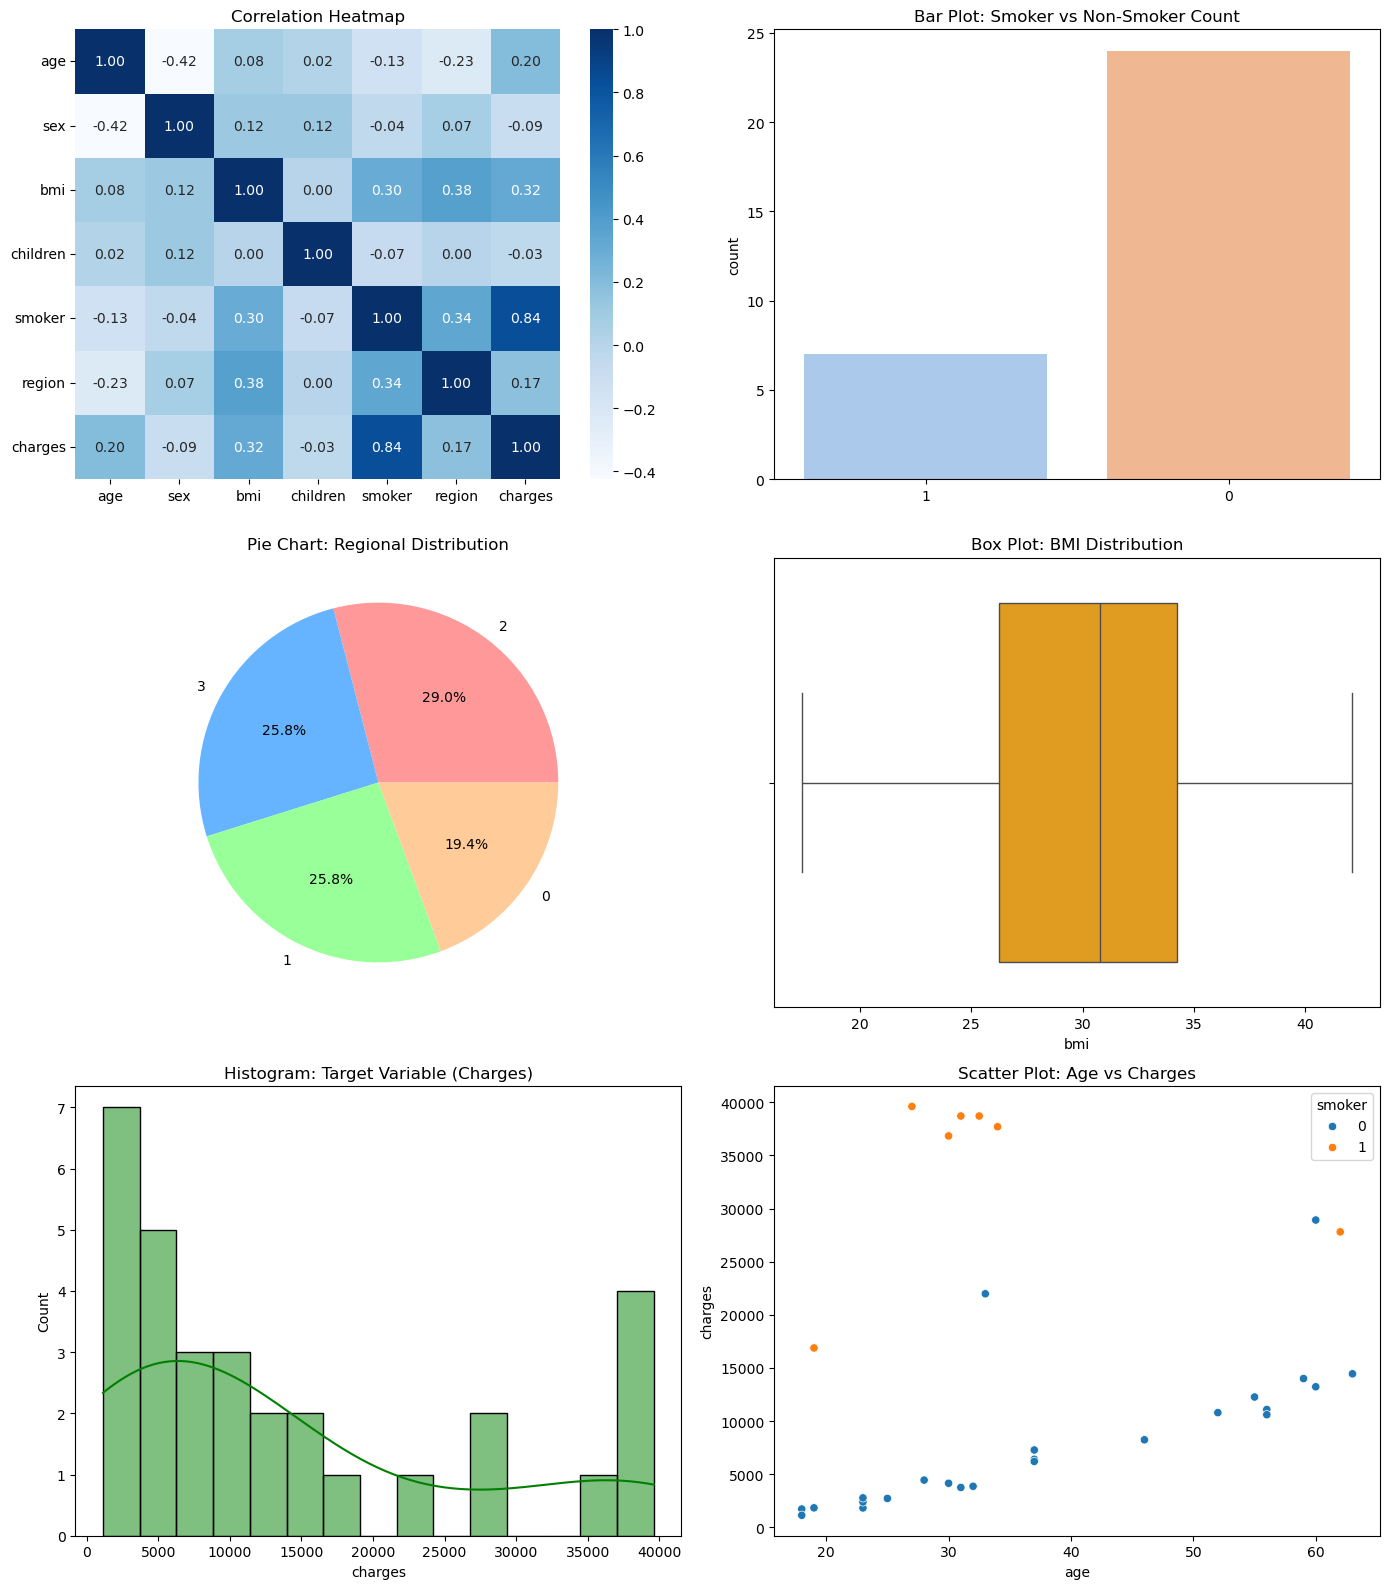

In [13]:
# ==========================================
# 4. DATA VISUALIZATION
# ==========================================
print("\n--- 4.1 Generating Visualizations ---")
fig, axes = plt.subplots(3, 2, figsize=(14, 16))

# Heatmap (Correlation Matrix)
sns.heatmap(df.corr(), annot=True, cmap='Blues', fmt=".2f", ax=axes[0, 0])
axes[0, 0].set_title('Correlation Heatmap')

# Bar Plot
smoker_labels = le_smoker.inverse_transform(df['smoker'])

sns.countplot(
    x=smoker_labels,
    hue=smoker_labels,
    palette='pastel',
    legend=False,
    ax=axes[0, 1]
)

axes[0, 1].set_title('Bar Plot: Smoker vs Non-Smoker Count')

# Pie Chart
region_counts = df['region'].value_counts()
axes[1, 0].pie(region_counts, labels=le_region.inverse_transform(region_counts.index), autopct='%1.1f%%', 
               colors=['#ff9999','#66b3ff','#99ff99','#ffcc99'])
axes[1, 0].set_title('Pie Chart: Regional Distribution')

# Box Plot
sns.boxplot(x=df['bmi'], ax=axes[1, 1], color='orange')
axes[1, 1].set_title('Box Plot: BMI Distribution')

# Histogram
sns.histplot(df['charges'], bins=15, kde=True, ax=axes[2, 0], color='green')
axes[2, 0].set_title('Histogram: Target Variable (Charges)')

# Scatter Plot
sns.scatterplot(data=df, x='age', y='charges', hue='smoker', ax=axes[2, 1])
axes[2, 1].set_title('Scatter Plot: Age vs Charges')

plt.tight_layout()
plt.show()